# Interaction matrix and modal calibration

This notebook demonstrates two successive calibration steps:

1. **Reference-basis calibration** — push-pull the deformable mirror in a Zernike basis.
2. **Modal calibration** — compute the SVD of the interaction matrix, use the right-singular vectors as DM eigenmodes, and calibrate the system again directly in this eigenbasis.

For a linearized sensor model,

$s = M a$,

the interaction matrix can be decomposed as

$M = U \Sigma V^\mathrm{T}$.

The columns of \(V\) define orthogonal combinations of the original DM commands. These are the **DM eigenmodes** of the calibrated system.

If we define modal coefficients \(m\) through

$a = V m$,

then

$s = M V m = U \Sigma m$.

The modal interaction matrix should therefore be close to $U\Sigma$: its columns are orthogonal sensor responses ordered by sensitivity.

In [1]:
import math

import torch
import matplotlib.pyplot as plt

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import Band, Spectrum
from fiatlux.core.source import PlaneWave

from fiatlux.optics.elements.mask import CircularAperture
from fiatlux.optics.elements.deformable_mirror import (
    ActuatorGrid,
    DeformableMirror,
    ZernikeBasis,
)
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.optics.detector import Detector

from fiatlux.system.optical_system import SerialSystem
from fiatlux.system.interaction_matrix import InteractionMatrix

## Optical setup

We use a small monochromatic system so that calibration remains fast.

The first DM is controlled with a Zernike basis. This is our **reference command basis**.

In [2]:
D = 1.0
wavelength = 1.65e-6
focal_length = 10.0

N_pupil = 128
N_focal = 128

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * wavelength / D / 4,
    dy=focal_length * wavelength / D / 4,
)

band = Band(
    central_wavelength=wavelength,
    delta_wavelength=0.0,
    f0=368.0,
)

spectrum = Spectrum(
    magnitude=0,
    band=band,
    samples=1,
)

source = PlaneWave(spectrum=spectrum)

aperture = CircularAperture(
    grid=pupil_grid,
    radius=D / 2,
)

propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

## Create the reference DM basis

We start from 12 Zernike modes.

`DeformableMirror` currently requires an `ActuatorGrid` even for a modal basis, so a dummy one-actuator grid is supplied here.

In [3]:
n_reference_modes = 32

reference_basis = ZernikeBasis(
    pixel_grid=pupil_grid,
    n=n_reference_modes,
)

actuator_grid = ActuatorGrid(
    n_actuators_x=1,
    n_actuators_y=1,
    pitch=D,
)

dm = DeformableMirror(
    grid=pupil_grid,
    actuator_grid=actuator_grid,
    pixel_grid=pupil_grid,
    control_basis=reference_basis,
    stroke=500e-9,
)

print("Number of reference modes:", dm.commands.numel())

Number of reference modes: 32


/Users/janinpop/Documents/code/fiatlux/.venv/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Build the calibration system

For this tutorial the measurement vector is the detector image flattened by `InteractionMatrix`.

The same calibration machinery can be used with another wavefront-sensor measurement by changing only the acquisition function.

In [4]:
calibration_system = SerialSystem(
    elements=[
        aperture,
        dm,
        propagator,
    ]
)

detector = Detector(
    grid=focal_grid,
    photon_noise=False,
    readout_noise_variance=0,
    dark_current=0,
)


def acquire_image():
    calibration_system.run(
        source=source,
        detector=detector,
    )

    return detector.image_buffer.clone()

## Reference-basis push-pull calibration

For each Zernike command $a_i$, Fiatlux measures

$M_i =
\frac{
s(+\epsilon_i)-s(-\epsilon_i)
}{
2\epsilon
}$.

In [5]:
reference_calibration = InteractionMatrix(
    dm=dm,
    poke_amplitude=0.02,
    acquiring_function=acquire_image,
)

M = reference_calibration.push_pull(
    verbose=True,
)

print("Reference interaction matrix shape:", M.shape)

Push-pull actuator 32/32
Push-pull matrix : torch.Size([16384, 32])
Reference interaction matrix shape: torch.Size([16384, 32])


## Singular-value decomposition

We compute the complete SVD without truncating it yet.

- `U` contains orthonormal sensor-response modes.
- `S` contains their sensitivities.
- `Vh` contains the corresponding eigenmodes in DM command space.

In [6]:
U, S, Vh = torch.linalg.svd(
    M,
    full_matrices=False,
)

print("U shape: ", U.shape)
print("S shape: ", S.shape)
print("Vh shape:", Vh.shape)

U shape:  torch.Size([16384, 32])
S shape:  torch.Size([32])
Vh shape: torch.Size([32, 32])


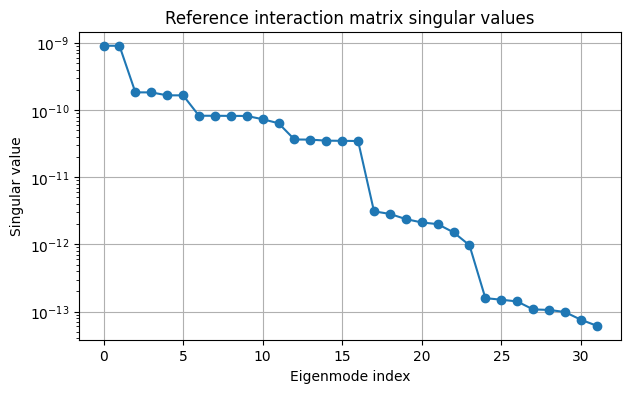

In [7]:
plt.figure(figsize=(7, 4))

plt.plot(
    torch.arange(len(S)).cpu(),
    S.cpu(),
    "o-",
)

plt.yscale("log")
plt.xlabel("Eigenmode index")
plt.ylabel("Singular value")
plt.title("Reference interaction matrix singular values")
plt.grid()
plt.show()

## DM eigenmodes

The rows of `Vh` are the right-singular vectors of the interaction matrix.

Each right-singular vector is a combination of the original Zernike commands:

$a_k = V_k$.

To visualize an eigenmode in the pupil plane, we apply this command vector to the original DM command matrix.

In [8]:
n_eigenmodes = min(32, Vh.shape[0])

# Columns are eigenmode command vectors expressed in the original Zernike basis.
eigen_commands = Vh[:n_eigenmodes, :].T.contiguous()

# Convert command-space eigenvectors into pupil-plane OPD maps.
# Shape: (n_pixels, n_eigenmodes)
eigenmode_opd_vectors = dm._command_matrix @ eigen_commands * dm.stroke

# Shape: (n_eigenmodes, ny, nx)
eigenmode_opd = eigenmode_opd_vectors.T.reshape(
    n_eigenmodes,
    pupil_grid.ny,
    pupil_grid.nx,
)

# The aperture has been built during the calibration runs.
pupil_support = aperture.transmission.to(torch.bool)

print("Eigenmode command matrix shape:", eigen_commands.shape)
print("Eigenmode OPD cube shape:", eigenmode_opd.shape)

Eigenmode command matrix shape: torch.Size([32, 32])
Eigenmode OPD cube shape: torch.Size([32, 128, 128])


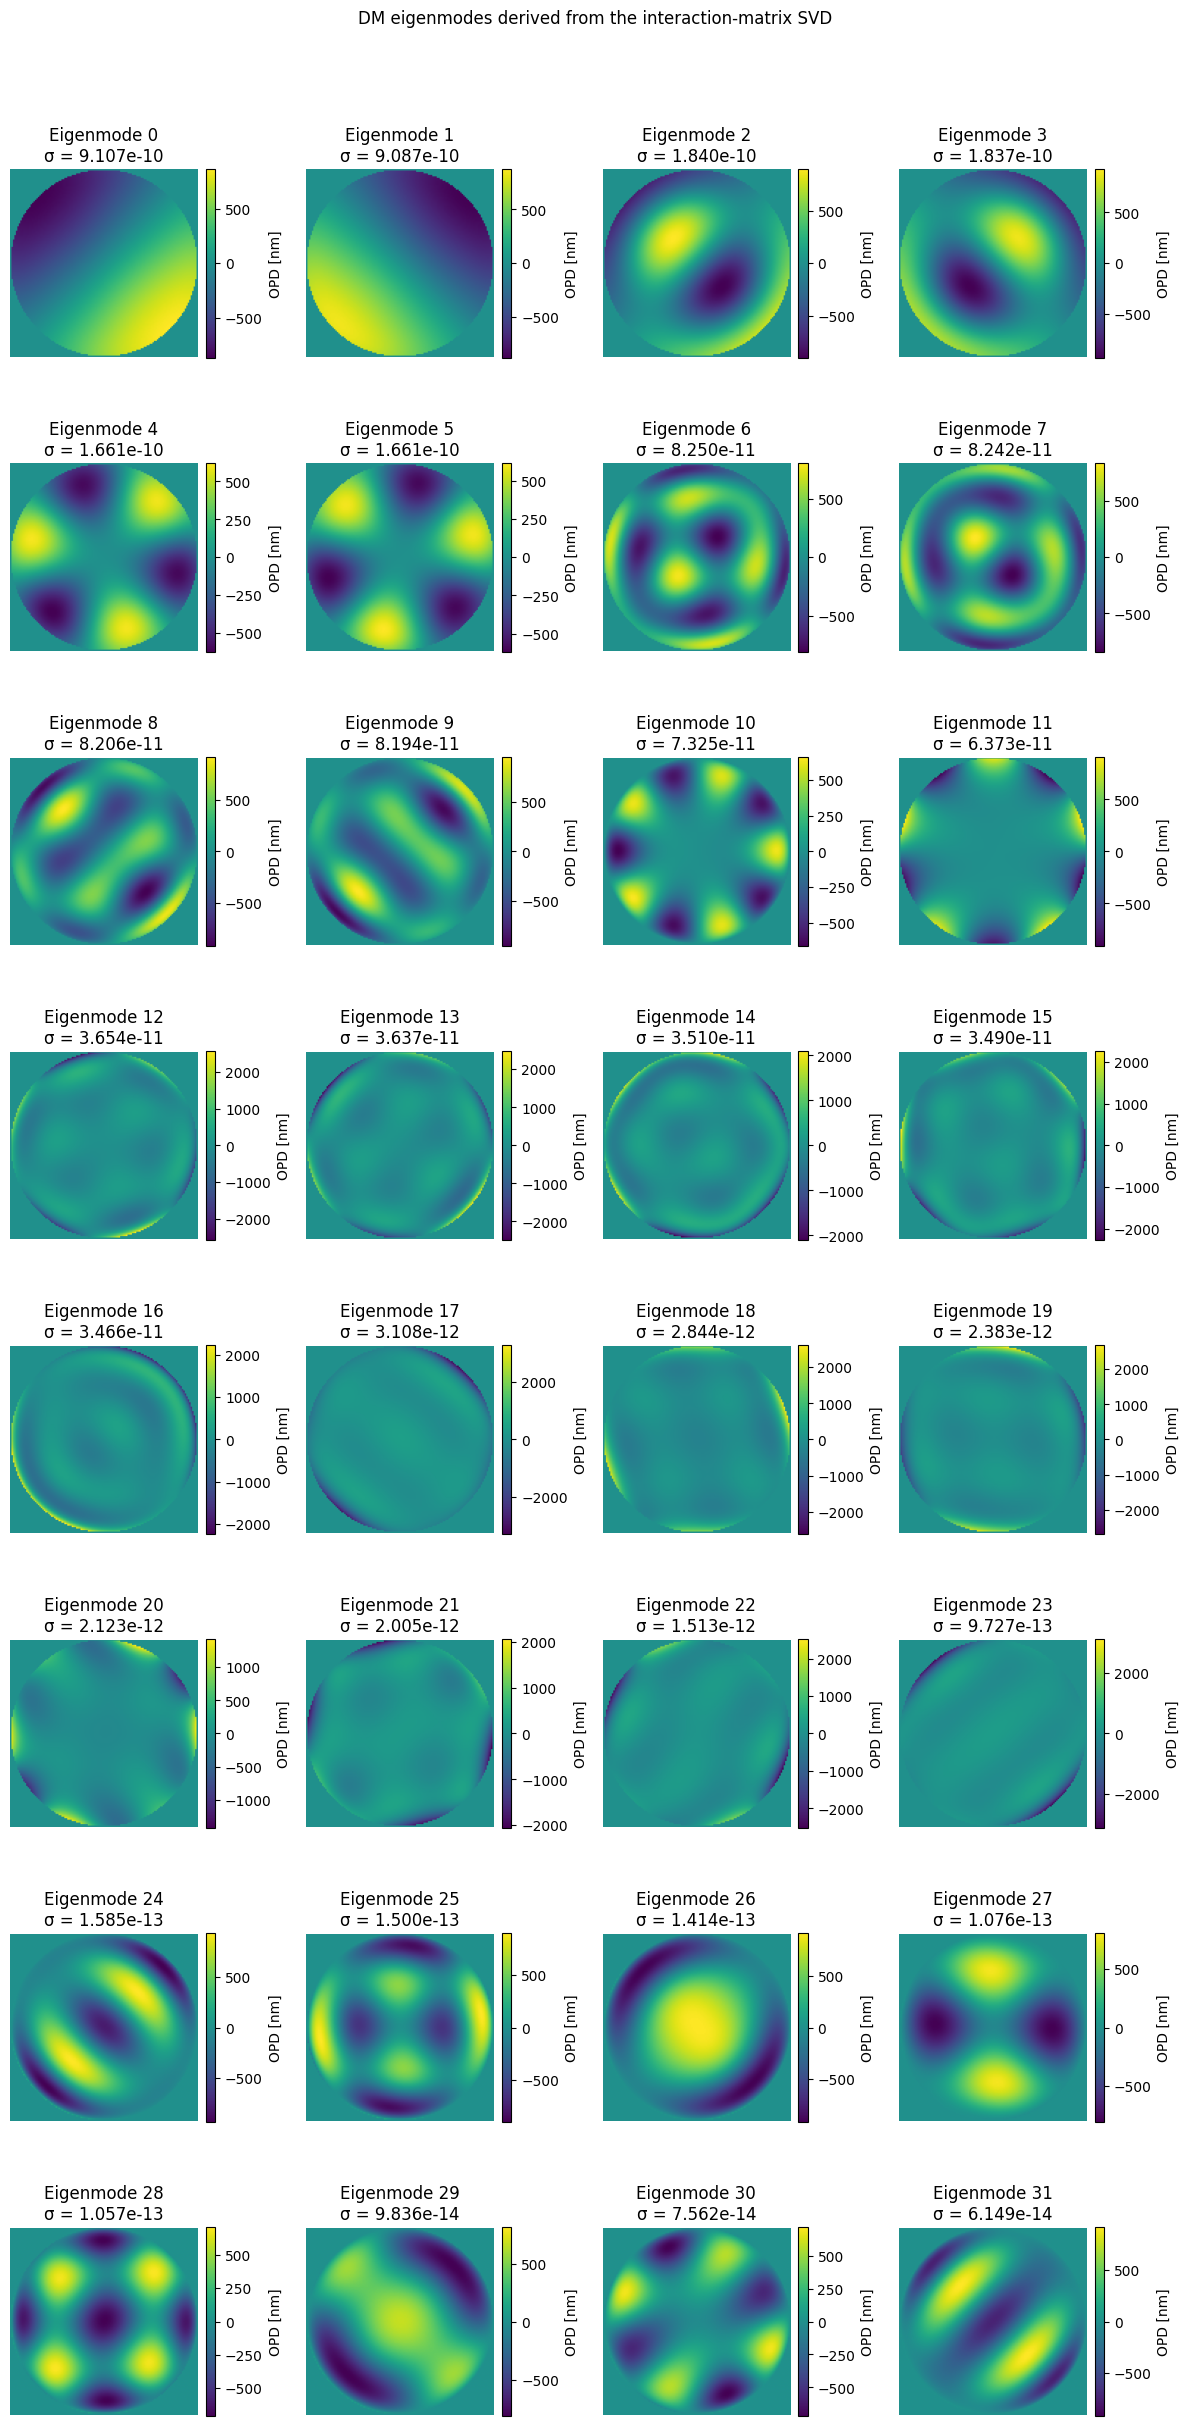

In [9]:
ncols = 4
nrows = math.ceil(n_eigenmodes / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 3 * nrows),
)

axes = torch.as_tensor([]) if False else axes
axes_flat = axes.flat if hasattr(axes, "flat") else [axes]

for k, ax in enumerate(axes_flat):

    if k >= n_eigenmodes:
        ax.axis("off")
        continue

    mode_nm = eigenmode_opd[k].cpu() * 1e9
    support = pupil_support.cpu()

    max_abs = mode_nm[support].abs().max()

    image = ax.imshow(
        mode_nm,
        origin="lower",
        vmin=-float(max_abs),
        vmax=float(max_abs),
    )

    ax.set_title(f"Eigenmode {k}\n" f"σ = {float(S[k]):.3e}")
    ax.axis("off")

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label="OPD [nm]",
    )

plt.suptitle(
    "DM eigenmodes derived from the interaction-matrix SVD",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Eigenmode coefficients in the original Zernike basis

The same modes can be inspected directly in command space.

Each row below is one eigenmode and each column is one original Zernike coefficient.

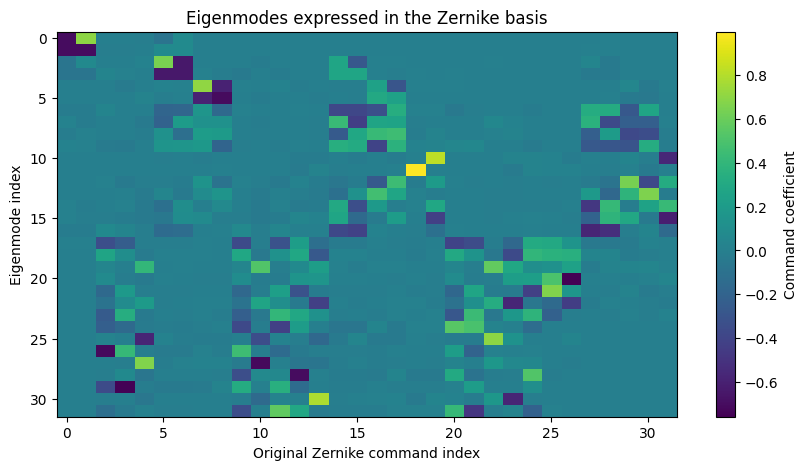

In [10]:
plt.figure(figsize=(10, 5))

plt.imshow(
    eigen_commands.T.cpu(),
    aspect="auto",
)

plt.xlabel("Original Zernike command index")
plt.ylabel("Eigenmode index")
plt.title("Eigenmodes expressed in the Zernike basis")
plt.colorbar(label="Command coefficient")
plt.show()

## Sensor eigenresponses

The columns of $U$ are the corresponding orthonormal modes in measurement space.

Because the measurement is a focal-plane image in this example, they can be reshaped and displayed as images.

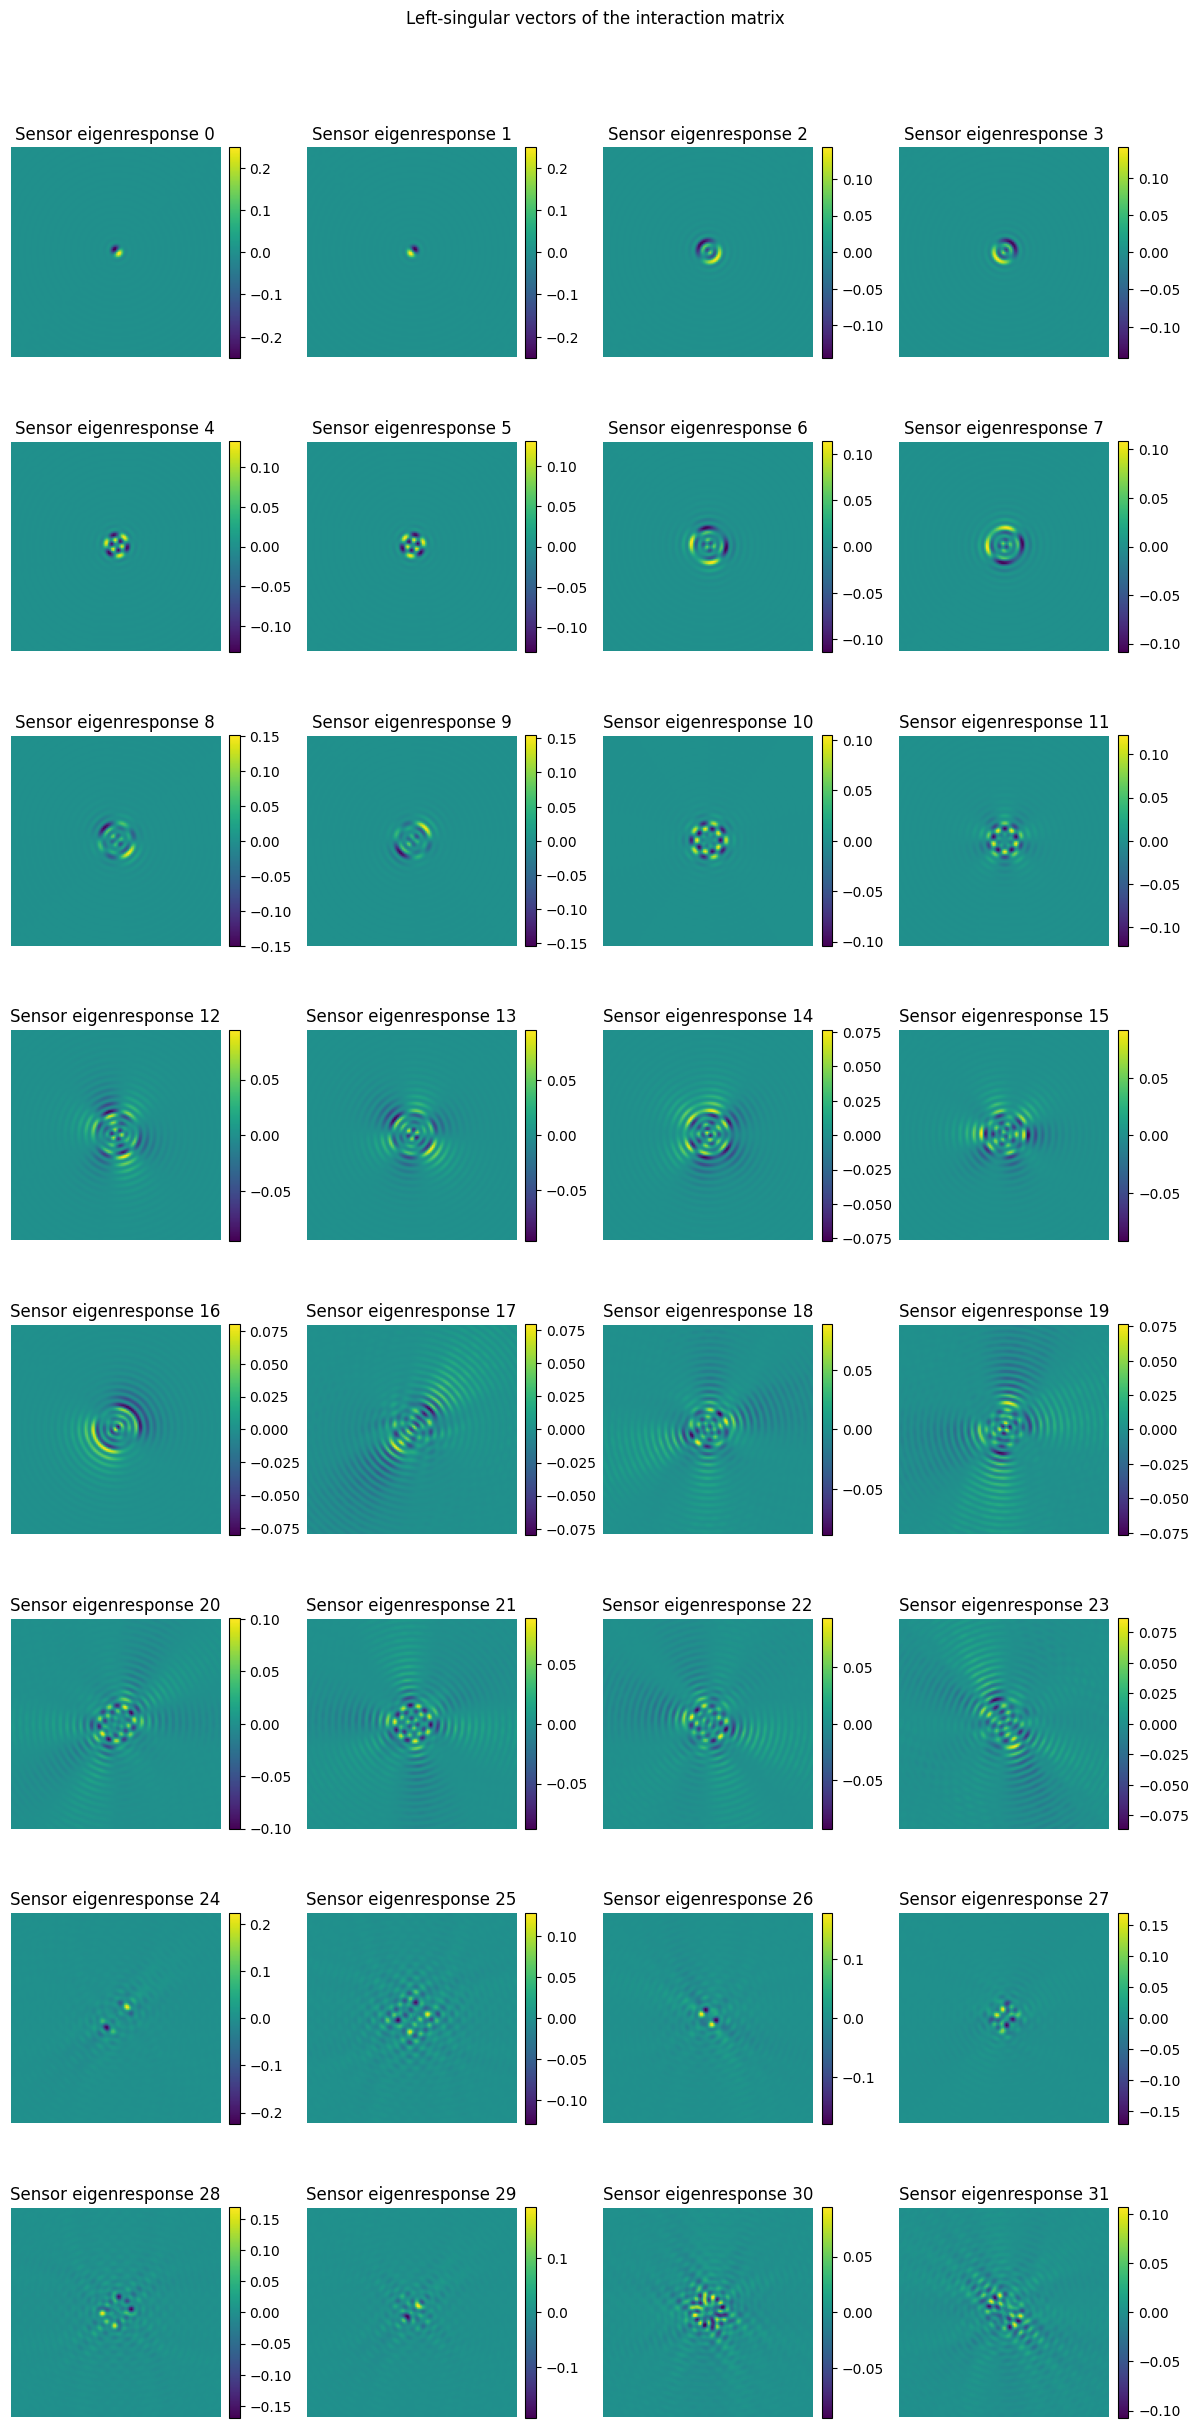

In [11]:
sensor_eigenresponses = U[:, :n_eigenmodes].T.reshape(
    n_eigenmodes,
    focal_grid.ny,
    focal_grid.nx,
)

ncols = 4
nrows = math.ceil(n_eigenmodes / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 3 * nrows),
)

axes_flat = axes.flat if hasattr(axes, "flat") else [axes]

for k, ax in enumerate(axes_flat):

    if k >= n_eigenmodes:
        ax.axis("off")
        continue

    mode = sensor_eigenresponses[k].cpu()
    max_abs = mode.abs().max()

    image = ax.imshow(
        mode,
        origin="lower",
        vmin=-float(max_abs),
        vmax=float(max_abs),
    )

    ax.set_title(f"Sensor eigenresponse {k}")
    ax.axis("off")

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

plt.suptitle(
    "Left-singular vectors of the interaction matrix",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Modal calibration

We now create a second control basis whose commands are the SVD eigenmodes.

If $B$ is the original DM command matrix and $V_r$ contains the retained eigenvectors, the modal DM command matrix is

$B_\mathrm{modal} = B V_r$.

A command of `[1, 0, 0, ...]` on this DM therefore applies eigenmode 0 rather than Zernike mode 0.

In [12]:
class EigenModeBasis:
    """Control basis built from eigenmodes of an existing DM basis."""

    def __init__(
        self,
        base_command_matrix: torch.Tensor,
        eigen_commands: torch.Tensor,
    ):
        self.base_command_matrix = base_command_matrix
        self.eigen_commands = eigen_commands

    def build_command_matrix(self):
        return self.base_command_matrix @ self.eigen_commands

    def n_modes(self):
        return self.eigen_commands.shape[1]


modal_basis = EigenModeBasis(
    base_command_matrix=dm._command_matrix.clone(),
    eigen_commands=eigen_commands,
)

modal_dm = DeformableMirror(
    grid=pupil_grid,
    actuator_grid=actuator_grid,
    pixel_grid=pupil_grid,
    control_basis=modal_basis,
    stroke=dm.stroke,
)

print("Number of calibrated eigenmodes:", modal_dm.commands.numel())

Number of calibrated eigenmodes: 32


## Build the modal calibration system

The optical system is unchanged. Only the DM command basis is different.

In [13]:
modal_system = SerialSystem(
    elements=[
        aperture,
        modal_dm,
        propagator,
    ]
)

modal_detector = Detector(
    grid=focal_grid,
    photon_noise=False,
    readout_noise_variance=0,
    dark_current=0,
)


def acquire_modal_image():
    modal_system.run(
        source=source,
        detector=modal_detector,
    )

    return modal_detector.image_buffer.clone()

## Direct push-pull calibration of the eigenmodes

In [14]:
modal_calibration = InteractionMatrix(
    dm=modal_dm,
    poke_amplitude=0.02,
    acquiring_function=acquire_modal_image,
)

M_modal = modal_calibration.push_pull(
    verbose=True,
)

print("Modal interaction matrix shape:", M_modal.shape)

Push-pull actuator 32/32
Push-pull matrix : torch.Size([16384, 32])
Modal interaction matrix shape: torch.Size([16384, 32])


In the linear regime, the modal interaction matrix predicted from the reference calibration is

$M_\mathrm{modal,predicted} = M V_r$.

A direct modal calibration should reproduce this matrix closely.

In [15]:
M_modal_predicted = M @ eigen_commands

relative_modal_error = torch.linalg.vector_norm(
    M_modal - M_modal_predicted
) / torch.linalg.vector_norm(M_modal_predicted)

print(
    "Relative difference between direct and predicted modal calibration:",
    float(relative_modal_error),
)

Relative difference between direct and predicted modal calibration: 0.0007380038732662797


## Compare reference and modal sensitivities

The singular values of the original calibration should correspond to the norms of the modal responses.

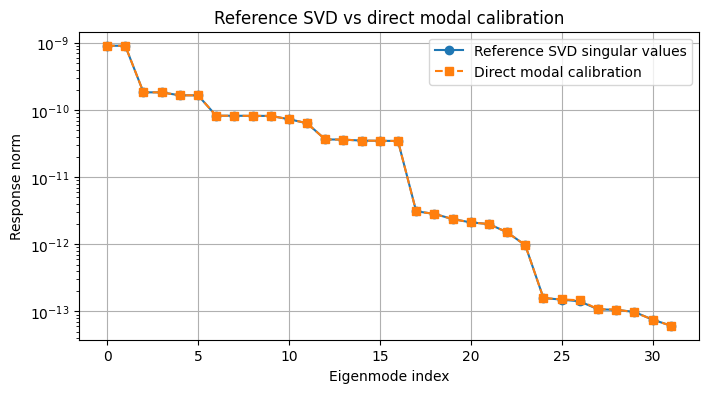

In [16]:
modal_response_norms = torch.linalg.vector_norm(
    M_modal,
    dim=0,
)

plt.figure(figsize=(8, 4))

plt.plot(
    torch.arange(n_eigenmodes).cpu(),
    S[:n_eigenmodes].cpu(),
    "o-",
    label="Reference SVD singular values",
)

plt.plot(
    torch.arange(n_eigenmodes).cpu(),
    modal_response_norms.cpu(),
    "s--",
    label="Direct modal calibration",
)

plt.yscale("log")
plt.xlabel("Eigenmode index")
plt.ylabel("Response norm")
plt.title("Reference SVD vs direct modal calibration")
plt.grid()
plt.legend()
plt.show()

## Check modal orthogonality

For ideal eigenmodes in the linear regime,

$M_\mathrm{modal}^{T}M_\mathrm{modal}$

should be diagonal.

The normalized Gram matrix below should therefore be close to the identity matrix.

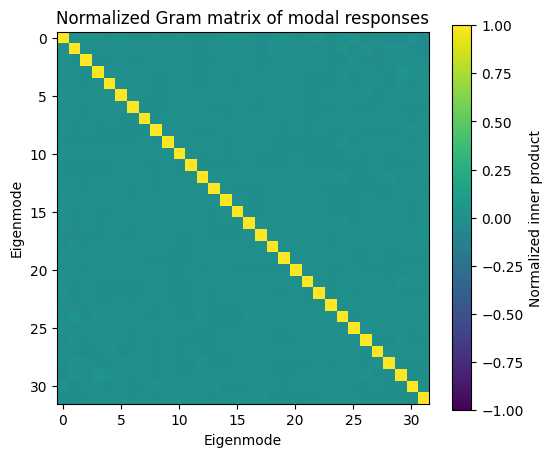

In [17]:
gram = M_modal.T @ M_modal

norms = torch.sqrt(torch.diag(gram)).clamp_min(1e-20)

normalized_gram = gram / norms[:, None] / norms[None, :]

plt.figure(figsize=(6, 5))
plt.imshow(
    normalized_gram.cpu(),
    vmin=-1,
    vmax=1,
)

plt.xlabel("Eigenmode")
plt.ylabel("Eigenmode")
plt.title("Normalized Gram matrix of modal responses")
plt.colorbar(label="Normalized inner product")
plt.show()

## Compute a control matrix in the eigenmode basis

The control matrix returned here estimates **modal coefficients**.

To convert those modal coefficients back into the original Zernike-command coordinates, multiply by `eigen_commands`.

In [18]:
modal_calibration.compute_control_matrix(
    n_modes=n_eigenmodes,
)

modal_control_matrix = modal_calibration.control_matrix

# Measurement vector -> original Zernike command coefficients
reference_command_control_matrix = eigen_commands @ modal_control_matrix

print(
    "Modal control matrix shape:",
    modal_control_matrix.shape,
)

print(
    "Control matrix in original Zernike coordinates:",
    reference_command_control_matrix.shape,
)

Modal control matrix shape: torch.Size([32, 16384])
Control matrix in original Zernike coordinates: torch.Size([32, 16384])


## Summary

The complete calibration chain is now:

```text
Original Zernike basis
        ↓
push-pull calibration
        ↓
interaction matrix M
        ↓
SVD: M = U Σ Vᵀ
        ↓
DM eigenmodes = columns of V
        ↓
construct eigenmode DM basis
        ↓
direct modal push-pull calibration
        ↓
modal interaction matrix ≈ U Σ
        ↓
modal control matrix
```

This is useful when only the best-observed modes should be retained in the control basis.

The right-singular vectors (`Vh`) are the **input/DM eigenmodes**, while the left-singular vectors (`U`) are the corresponding **sensor eigenresponses**.